<h2>EM / Gaussian Mixture Model for 2D Anomaly Detection</h2>

<h3>Algorithm Description</h3>

<p>
This example uses the <b>Expectation-Maximization (EM)</b> algorithm through a
<b>Gaussian Mixture Model (GMM)</b>. The goal is to learn the normal structure
of a 2D dataset and then detect new points that are unlikely to belong to the
same distribution.
</p>

<p>
The GMM assumes that the data was generated from multiple Gaussian clusters.
In this example, we use <b>2 Gaussian components</b>, meaning the model tries
to learn two normal clusters in the data.
</p>

<h3>Dataset</h3>

<p>
The training dataset contains two normal 2D clusters:
</p>

<ul>
  <li><b>Cluster 1:</b> centered around <code>(2, 2)</code></li>
  <li><b>Cluster 2:</b> centered around <code>(8, 8)</code></li>
</ul>

<p>
Each point has two features:
</p>

<pre>
x = [feature_1, feature_2]
</pre>

<p>
The model is trained only on normal data. Later, we test it using both normal
points and abnormal points.
</p>

<h3>Threshold</h3>

<p>
After training, the model calculates a <b>log-likelihood score</b> for every
training point.
</p>

<pre>
train_scores = gmm.score_samples(X_train)
threshold = np.percentile(train_scores, 1)
</pre>

<p>
The threshold is set to the <b>1st percentile</b> of the training scores.
This means the lowest 1% of training likelihood scores define the anomaly
boundary.
</p>

<p>
If a new point has a log-likelihood score below this threshold, it is classified
as an anomaly.
</p>

<pre>
if new_score &lt; threshold:
    result = "Anomaly"
else:
    result = "Normal"
</pre>

<h3>Results</h3>

<p>
Normal points close to the learned clusters receive higher log-likelihood
scores and are classified as <b>Normal</b>.
</p>

<p>
Points far away from both clusters receive very low log-likelihood scores and
are classified as <b>Anomalies</b>.
</p>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Example Point</th>
    <th>Expected Result</th>
    <th>Reason</th>
  </tr>
  <tr>
    <td><code>[2.5, 2.2]</code></td>
    <td>Normal</td>
    <td>Close to Cluster 1</td>
  </tr>
  <tr>
    <td><code>[7.5, 8.3]</code></td>
    <td>Normal</td>
    <td>Close to Cluster 2</td>
  </tr>
  <tr>
    <td><code>[15, 15]</code></td>
    <td>Anomaly</td>
    <td>Far from both clusters</td>
  </tr>
  <tr>
    <td><code>[-5, 3]</code></td>
    <td>Anomaly</td>
    <td>Far from the learned normal distribution</td>
  </tr>
</table>

<h3>Summary</h3>

<p>
The EM algorithm learns the hidden Gaussian clusters in the data. The trained
GMM then assigns a probability density to each new point. Points with very low
probability are considered anomalies.
</p>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [3]:
# ----------------------------
# Generate 2 normal clusters
# ----------------------------
np.random.seed(42)

cluster1 = np.random.multivariate_normal(
    mean=[2, 2],
    cov=[[1, 0.3],
         [0.3, 1]],
    size=200
)

cluster2 = np.random.multivariate_normal(
    mean=[8, 8],
    cov=[[1, -0.2],
         [-0.2, 1]],
    size=200
)

In [4]:

# Training data (normal only)
X_train = np.vstack([cluster1, cluster2])

# ----------------------------
# Train GMM using EM
# ----------------------------
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_train)

,n_components,2
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [5]:
# ----------------------------
# Determine anomaly threshold
# ----------------------------
train_scores = gmm.score_samples(X_train)

# Lowest 1% likelihood
threshold = np.percentile(train_scores, 1)

print("Threshold:", threshold)

Threshold: -6.892407236297143


In [6]:

# ----------------------------
# Create new data
# ----------------------------
normal_points = np.array([
    [2.5, 2.2],
    [7.5, 8.3],
    [8.1, 7.2]
])

anomaly_points = np.array([
    [15, 15],
    [-5, 3],
    [5, 15]
])

In [8]:
X_test = np.vstack([normal_points, anomaly_points])

In [9]:

# ----------------------------
# Score new points
# ----------------------------
test_scores = gmm.score_samples(X_test)

predicted_anomalies = X_test[test_scores < threshold]
predicted_normal = X_test[test_scores >= threshold]

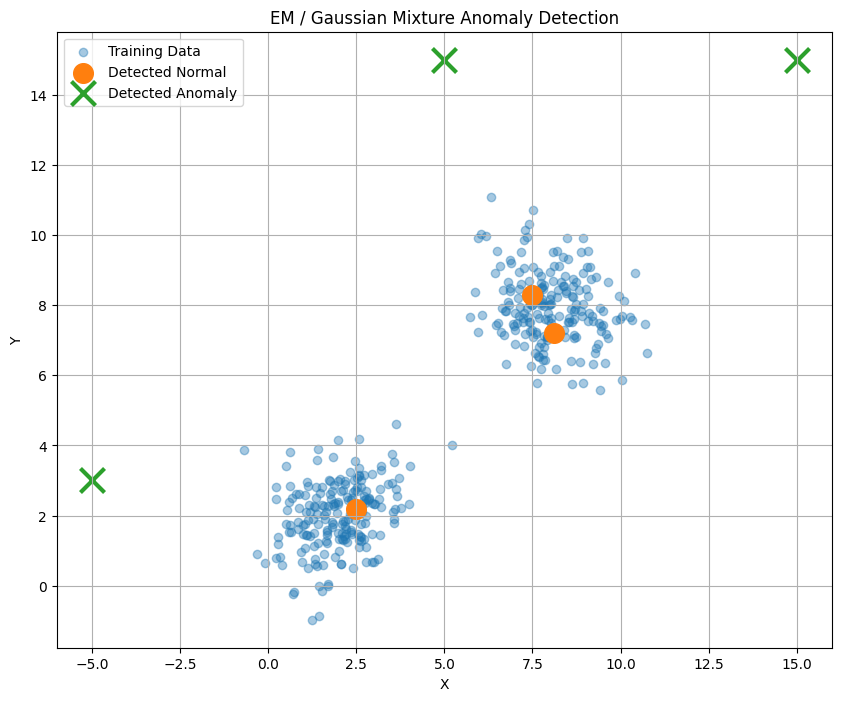

In [11]:

# ----------------------------
# Visualize
# ----------------------------
plt.figure(figsize=(10, 8))

# Training data
plt.scatter(
    X_train[:,0],
    X_train[:,1],
    alpha=0.4,
    label='Training Data'
)

# New normal points
plt.scatter(
    predicted_normal[:,0],
    predicted_normal[:,1],
    s=200,
    marker='o',
    label='Detected Normal'
)

# New anomalies
plt.scatter(
    predicted_anomalies[:,0],
    predicted_anomalies[:,1],
    s=300,
    marker='x',
    linewidths=3,
    label='Detected Anomaly'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("EM / Gaussian Mixture Anomaly Detection")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Print scores
for point, score in zip(X_test, test_scores):
    print(
        f"Point {point} | Log-Likelihood={score:.2f} | "
        f"{'ANOMALY' if score < threshold else 'NORMAL'}"
    )

Point [2.5 2.2] | Log-Likelihood=-2.56 | NORMAL
Point [7.5 8.3] | Log-Likelihood=-2.69 | NORMAL
Point [8.1 7.2] | Log-Likelihood=-2.80 | NORMAL
Point [15. 15.] | Log-Likelihood=-63.77 | ANOMALY
Point [-5.  3.] | Log-Likelihood=-35.14 | ANOMALY
Point [ 5. 15.] | Log-Likelihood=-28.91 | ANOMALY
